# RDD2022 — Comparativa de experimentos DINOv1

Notebook para comparar los resultados de los tres experimentos realizados con DINOv1:

| Exp | dropout | épocas | hidden_dim |
|-----|---------|--------|------------|
| 1   | 0.3     | 80     | 512        |
| 2   | 0.5     | 80     | 512        |
| 3   | 0.5     | 20     | 256        |


In [ ]:
# Instalar dependencias si es necesario (descomentar en Colab)
# !pip install matplotlib numpy


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Estilo general ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "monospace",
    "figure.facecolor":  "#0F1117",
    "axes.facecolor":    "#171B26",
    "text.color":        "#E8EAF0",
    "axes.labelcolor":   "#E8EAF0",
    "xtick.color":       "#9AA0B4",
    "ytick.color":       "#9AA0B4",
    "axes.edgecolor":    "#2D3348",
    "grid.color":        "#2D3348",
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COLORS = {
    "exp1": "#378ADD",
    "exp2": "#E76F51",
    "exp3": "#2A9D8F",
    "D00":  "#F4A261",
    "D10":  "#2A9D8F",
    "D20":  "#E76F51",
}

CLASSES = ["D00", "D10", "D20"]

print("Imports correctos ✅")


Imports correctos ✅


## 1. Carga de los training reports

Ajusta las rutas a donde tengas guardados los tres archivos JSON.

In [6]:
# ── Ajusta estas rutas ──────────────────────────────────────────────
# En local (Windows):
REPORT_PATHS = {
    "Exp1 d=0.3 80ep h=512": r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2º CUATRI\PASD\BLOG\features_new\models\dinov1\training_report.json",
    "Exp2 d=0.5 80ep h=512": r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2º CUATRI\PASD\BLOG\features_new\models\dinov1\training_report_dropout05.json",
    "Exp3 d=0.5 20ep h=256": r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2º CUATRI\PASD\BLOG\features_new\models\dinov1\training_report_20_epochs_256_hidden.json",
}

# En Colab con Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# REPORT_PATHS = {
#     "Exp1 d=0.3 80ep h=512": "/content/drive/MyDrive/PASD BLOG/models/training_report.json",
#     "Exp2 d=0.5 80ep h=512": "/content/drive/MyDrive/PASD BLOG/models/training_report_dropout05.json",
#     "Exp3 d=0.5 20ep h=256": "/content/drive/MyDrive/PASD BLOG/models/training_report_20_epochs_256_hidden.json",
# }

# ── Carga ───────────────────────────────────────────────────────────
reports = {}
for name, path in REPORT_PATHS.items():
    with open(path, encoding="utf-8") as f:
        reports[name] = json.load(f)
    n_ep = len(reports[name]["history"])
    mf1  = reports[name]["test_metrics"]["macro_f1"]
    print(f"  {name}: {n_ep} épocas | Macro F1 test = {mf1:.4f} ✅")


  Exp1 d=0.3 80ep h=512: 20 épocas | Macro F1 test = 0.7399 ✅
  Exp2 d=0.5 80ep h=512: 66 épocas | Macro F1 test = 0.7249 ✅
  Exp3 d=0.5 20ep h=256: 20 épocas | Macro F1 test = 0.7298 ✅


## 2. Tabla resumen de resultados

In [7]:
print(f"{'Experimento':<28} {'Macro F1':>9} {'D00 F1':>8} {'D10 F1':>8} {'D20 F1':>8} {'Exact Acc':>10} {'Train F1':>10} {'Val loss':>10}")
print("─" * 100)

for name, rep in reports.items():
    tm   = rep["test_metrics"]
    hist = rep["history"]
    train_f1_final = hist[-1]["train_f1"]
    val_loss_final = hist[-1]["val_loss"]
    print(
        f"  {name:<26} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f} "
        f"{train_f1_final:>10.4f} "
        f"{val_loss_final:>10.4f} "
    )


Experimento                   Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc   Train F1   Val loss
────────────────────────────────────────────────────────────────────────────────────────────────────
  Exp1 d=0.3 80ep h=512         0.7399   0.8242   0.6098   0.7856     0.5459     0.8921     0.6800 
  Exp2 d=0.5 80ep h=512         0.7249   0.8104   0.6032   0.7612     0.5118     0.9157     0.6838 
  Exp3 d=0.5 20ep h=256         0.7298   0.8053   0.6157   0.7684     0.5004     0.8216     0.5401 


## 3. Curvas de entrenamiento

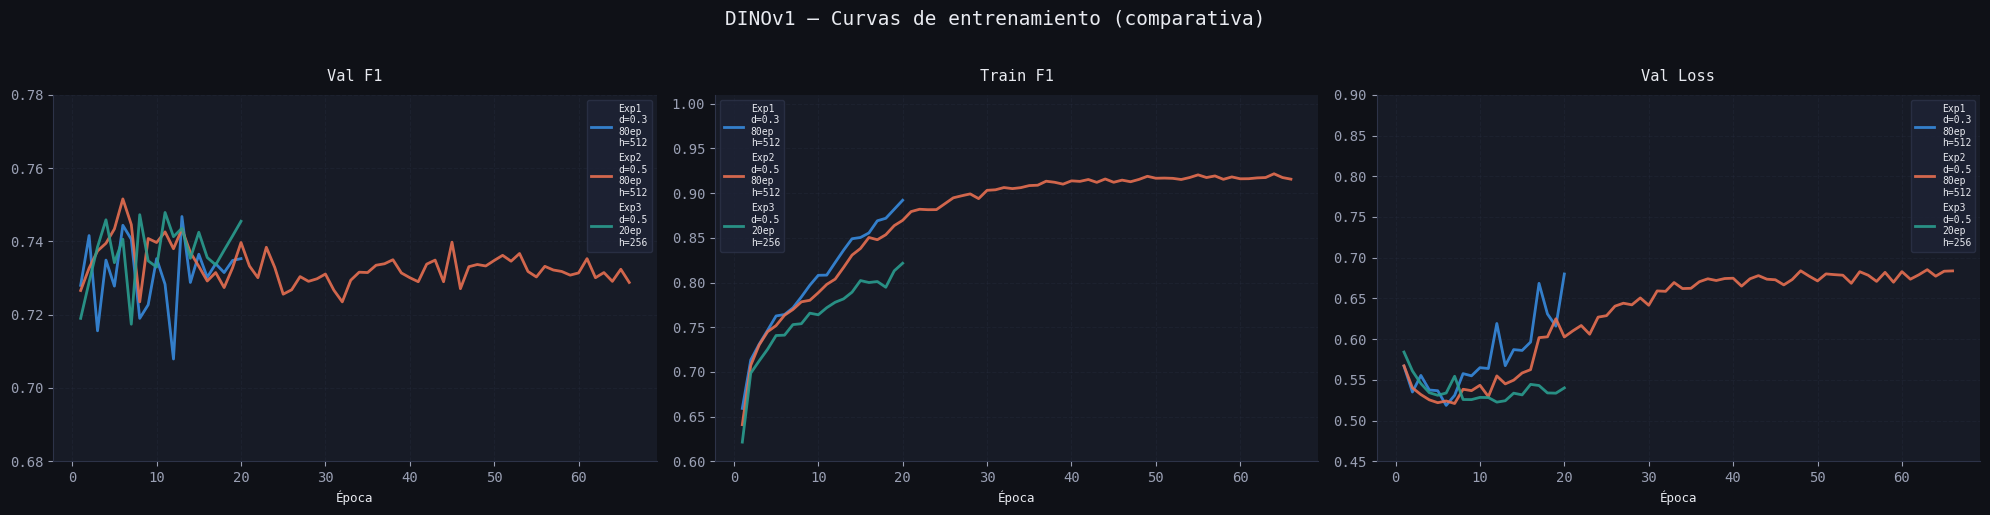

Figura guardada: curvas_entrenamiento.png


In [8]:
exp_colors = list(COLORS.values())[:3]
exp_names  = list(reports.keys())

fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 — Curvas de entrenamiento (comparativa)", fontsize=14, color="#E8EAF0", y=1.02)

titles   = ["Val F1", "Train F1", "Val Loss"]
keys_y   = ["val_f1", "train_f1", "val_loss"]
y_limits = [(0.68, 0.78), (0.60, 1.01), (0.45, 0.90)]

for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
    for (name, rep), color in zip(reports.items(), exp_colors):
        epochs = [h["epoch"]  for h in rep["history"]]
        values = [h[key]      for h in rep["history"]]
        ax.plot(epochs, values, color=color, linewidth=2,
                label=name.replace(" ", "\n"), alpha=0.9)

    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_xlabel("Época", fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(fontsize=7, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="best")

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: curvas_entrenamiento.png")


## 4. F1 por clase en test

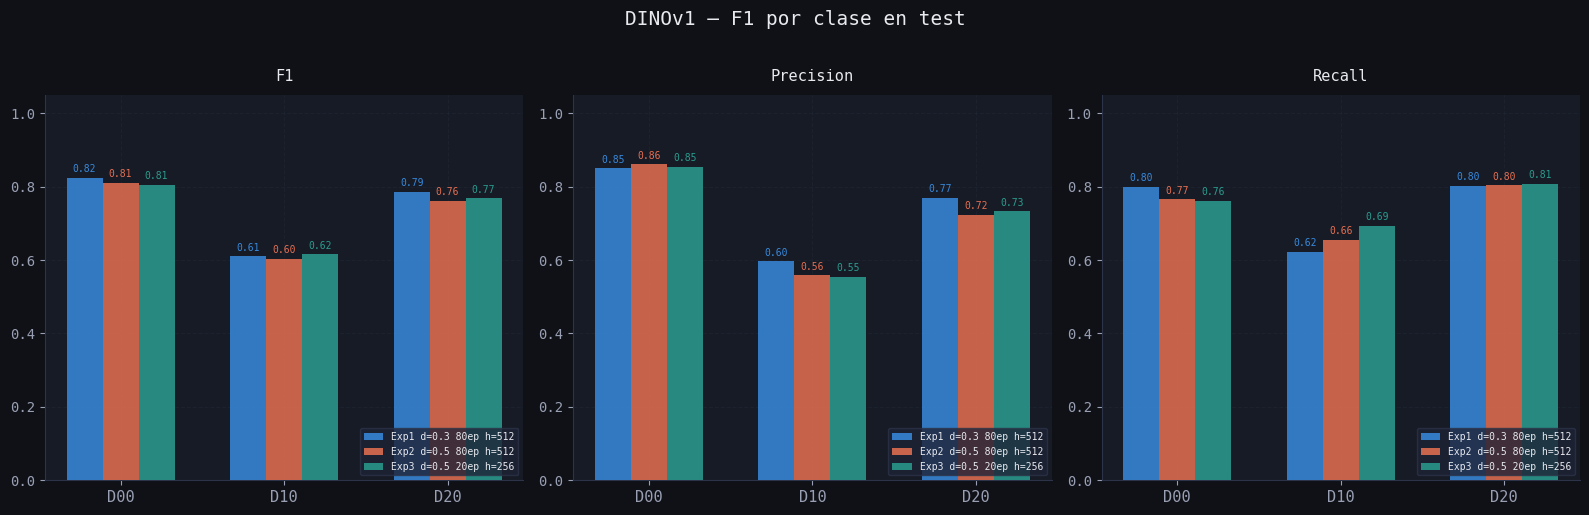

Figura guardada: f1_por_clase.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 — F1 por clase en test", fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x      = np.arange(len(CLASSES))
    n_exp  = len(reports)
    width  = 0.22
    offset = np.linspace(-(n_exp - 1) / 2, (n_exp - 1) / 2, n_exp) * width

    for (name, rep), color, off in zip(reports.items(), exp_colors, offset):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=name, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom",
                    fontsize=7, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("f1_por_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: f1_por_clase.png")


## 5. Análisis de overfitting

Diferencia entre train F1 y val F1 por época.
Cuanto más pequeña, menos overfitting.

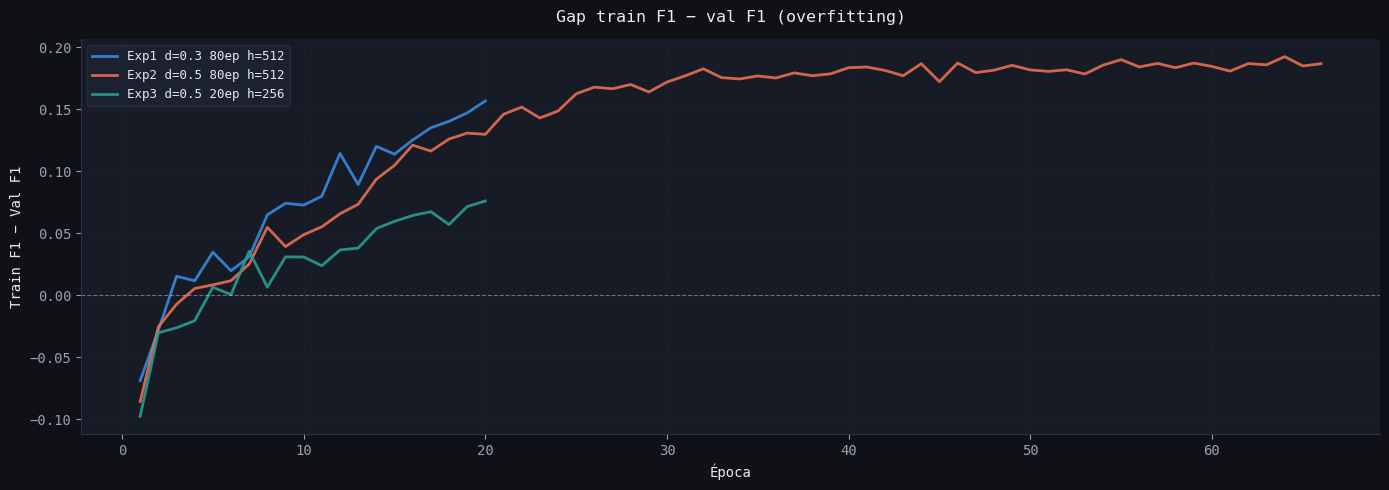

Figura guardada: overfitting_gap.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0F1117")

for (name, rep), color in zip(reports.items(), exp_colors):
    epochs = [h["epoch"]                    for h in rep["history"]]
    gap    = [h["train_f1"] - h["val_f1"]   for h in rep["history"]]
    ax.plot(epochs, gap, color=color, linewidth=2, label=name, alpha=0.9)

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Gap train F1 − val F1 (overfitting)", fontsize=12, color="#E8EAF0", pad=12)
ax.set_xlabel("Época", fontsize=10)
ax.set_ylabel("Train F1 − Val F1", fontsize=10)
ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: overfitting_gap.png")


## 6. Mejor época por experimento (según val F1)

In [11]:
print(f"{'Experimento':<30} {'Mejor época':>12} {'Mejor val F1':>14} {'val F1 final':>14}")
print("─" * 75)

for name, rep in reports.items():
    hist     = rep["history"]
    best     = max(hist, key=lambda h: h["val_f1"])
    last_vf1 = hist[-1]["val_f1"]
    print(
        f"  {name:<28} "
        f"{best['epoch']:>12} "
        f"{best['val_f1']:>14.4f} "
        f"{last_vf1:>14.4f}"
    )

print()
print("Nota: si 'mejor época' << nº total de épocas → overfitting temprano.")


Experimento                     Mejor época   Mejor val F1   val F1 final
───────────────────────────────────────────────────────────────────────────
  Exp1 d=0.3 80ep h=512                  13         0.7468         0.7353
  Exp2 d=0.5 80ep h=512                   6         0.7516         0.7288
  Exp3 d=0.5 20ep h=256                  11         0.7479         0.7455

Nota: si 'mejor época' << nº total de épocas → overfitting temprano.


## 7. Conclusión y siguiente paso

Los tres experimentos convergen en un Macro F1 test de ~0.725-0.730.

**Patrón observado:**
- D00 estable en ~0.82 (clase más fácil, más ejemplos)
- D20 mejora progresivamente: 0.753 → 0.761 → 0.768
- D10 sigue siendo el cuello de botella: ~0.60-0.62

La convergencia en el mismo techo de val F1 (~0.73-0.75) indica que
el límite no son los hiperparámetros sino las propias features de DINOv1.

**Siguiente paso: DINOv2** con la configuración del Exp3 como baseline:
```bash
python train_detector.py \
    --features C:/features/dinov2 \
    --output C:/models/dinov2 \
    --epochs 20 --dropout 0.5 --hidden-dim 256
```


---
## 8. DINOv1 vs DINOv2 — Mismos hiperparámetros (d=0.5, 20ep, h=256)

Comparativa controlada: el único factor que cambia son las **features** del backbone.

| | DINOv1 Exp3 | DINOv2 |
|---|---|---|
| Backbone | ViT-S/16 DINOv1 | ViT-S/14 DINOv2 |
| Dropout | 0.5 | 0.5 |
| Épocas | 20 | 20 |
| Hidden dim | 256 | 256 |

In [12]:
# ── Ruta al report de DINOv2 (mismos hiperparámetros que Exp3: d=0.5, 20ep, h=256) ──
DINOV2_PATH = r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2º CUATRI\PASD\BLOG\features_new\models\dinov2\training_report.json"

# En Colab con Google Drive:
# DINOV2_PATH = "/content/drive/MyDrive/PASD BLOG/models/dinov2/training_report_20_epochs_256_hidden.json"

with open(DINOV2_PATH, encoding="utf-8") as f:
    rep_v2 = json.load(f)

rep_v1   = reports["Exp3 d=0.5 20ep h=256"]  # referencia al Exp3 ya cargado
COLOR_V1 = "#2A9D8F"   # mismo color que Exp3 en la sección anterior
COLOR_V2 = "#C084FC"   # violeta para DINOv2

n_ep_v2 = len(rep_v2["history"])
mf1_v1  = rep_v1["test_metrics"]["macro_f1"]
mf1_v2  = rep_v2["test_metrics"]["macro_f1"]
print(f"  DINOv1 Exp3 (d=0.5 20ep h=256): Macro F1 test = {mf1_v1:.4f} ✅")
print(f"  DINOv2      (d=0.5 20ep h=256): {n_ep_v2} épocas | Macro F1 test = {mf1_v2:.4f} ✅")


  DINOv1 Exp3 (d=0.5 20ep h=256): Macro F1 test = 0.7298 ✅
  DINOv2      (d=0.5 20ep h=256): 20 épocas | Macro F1 test = 0.7523 ✅


In [13]:
print(f"{'Modelo':<28} {'Macro F1':>9} {'D00 F1':>8} {'D10 F1':>8} {'D20 F1':>8} {'Exact Acc':>10} {'Train F1':>10} {'Val loss':>10}")
print("─" * 100)

for label, rep in [("DINOv1 d=0.5 20ep h=256", rep_v1), ("DINOv2 d=0.5 20ep h=256", rep_v2)]:
    tm   = rep["test_metrics"]
    hist = rep["history"]
    print(
        f"  {label:<26} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f} "
        f"{hist[-1]['train_f1']:>10.4f} "
        f"{hist[-1]['val_loss']:>10.4f} "
    )


Modelo                        Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc   Train F1   Val loss
────────────────────────────────────────────────────────────────────────────────────────────────────
  DINOv1 d=0.5 20ep h=256       0.7298   0.8053   0.6157   0.7684     0.5004     0.8216     0.5401 
  DINOv2 d=0.5 20ep h=256       0.7523   0.8119   0.6562   0.7890     0.5208     0.7756     0.4940 


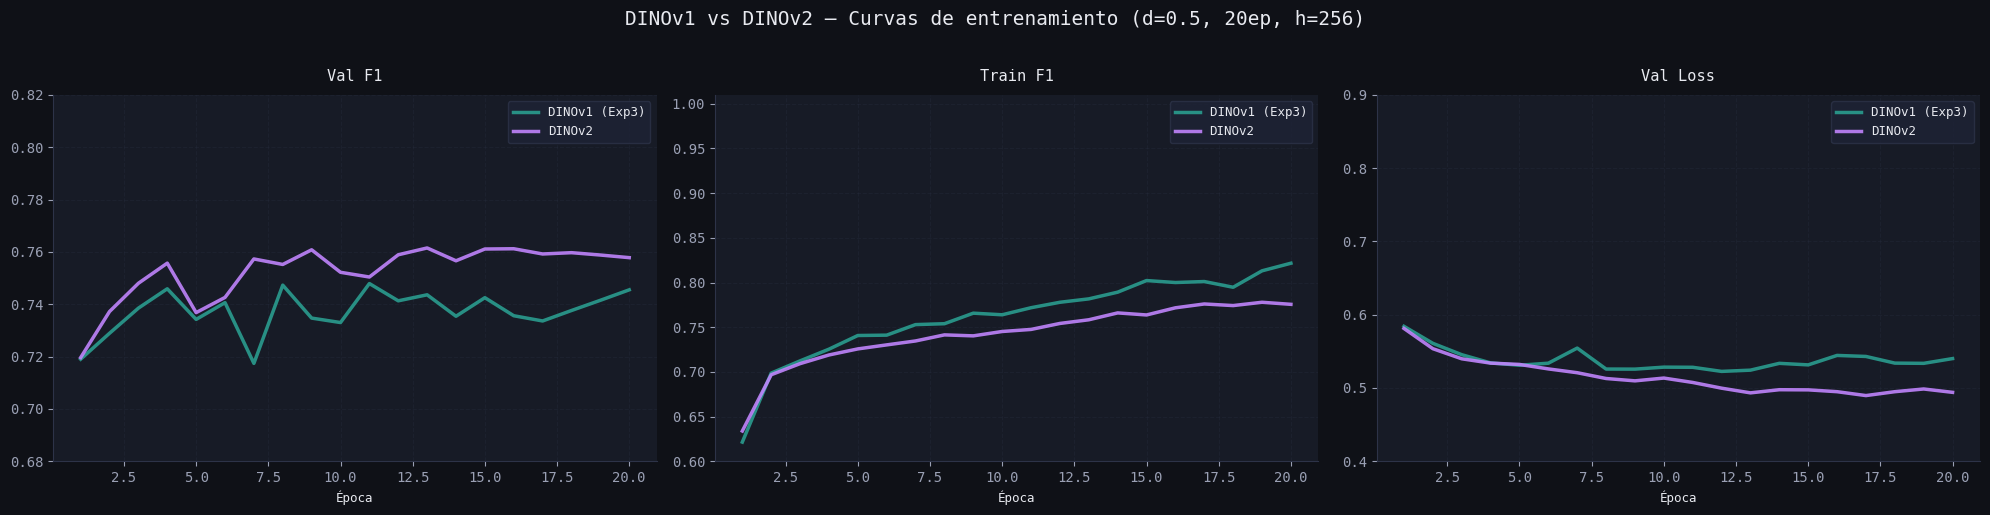

Figura guardada: dinov1_vs_v2_curvas.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 vs DINOv2 — Curvas de entrenamiento (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

titles   = ["Val F1", "Train F1", "Val Loss"]
keys_y   = ["val_f1", "train_f1", "val_loss"]
y_limits = [(0.68, 0.82), (0.60, 1.01), (0.40, 0.90)]

for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
    for label, rep, color in [
        ("DINOv1 (Exp3)", rep_v1, COLOR_V1),
        ("DINOv2",        rep_v2, COLOR_V2),
    ]:
        epochs = [h["epoch"] for h in rep["history"]]
        values = [h[key]     for h in rep["history"]]
        ax.plot(epochs, values, color=color, linewidth=2.5, label=label, alpha=0.9)

    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_xlabel("Época", fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="best")

plt.tight_layout()
plt.savefig("dinov1_vs_v2_curvas.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov1_vs_v2_curvas.png")


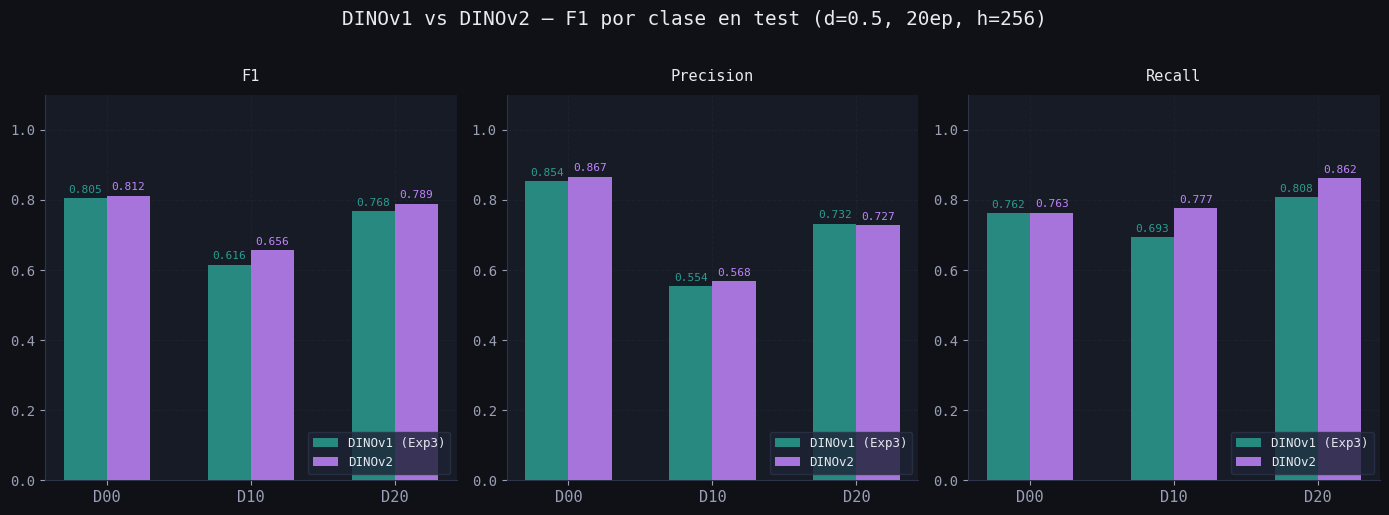

Figura guardada: dinov1_vs_v2_f1_clase.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor="#0F1117")
fig.suptitle("DINOv1 vs DINOv2 — F1 por clase en test (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

models  = [("DINOv1 (Exp3)", rep_v1, COLOR_V1), ("DINOv2", rep_v2, COLOR_V2)]
width   = 0.30
offsets = [-width / 2, width / 2]

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x = np.arange(len(CLASSES))
    for (label, rep, color), off in zip(models, offsets):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=label, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.10)
    ax.legend(fontsize=9, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("dinov1_vs_v2_f1_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov1_vs_v2_f1_clase.png")


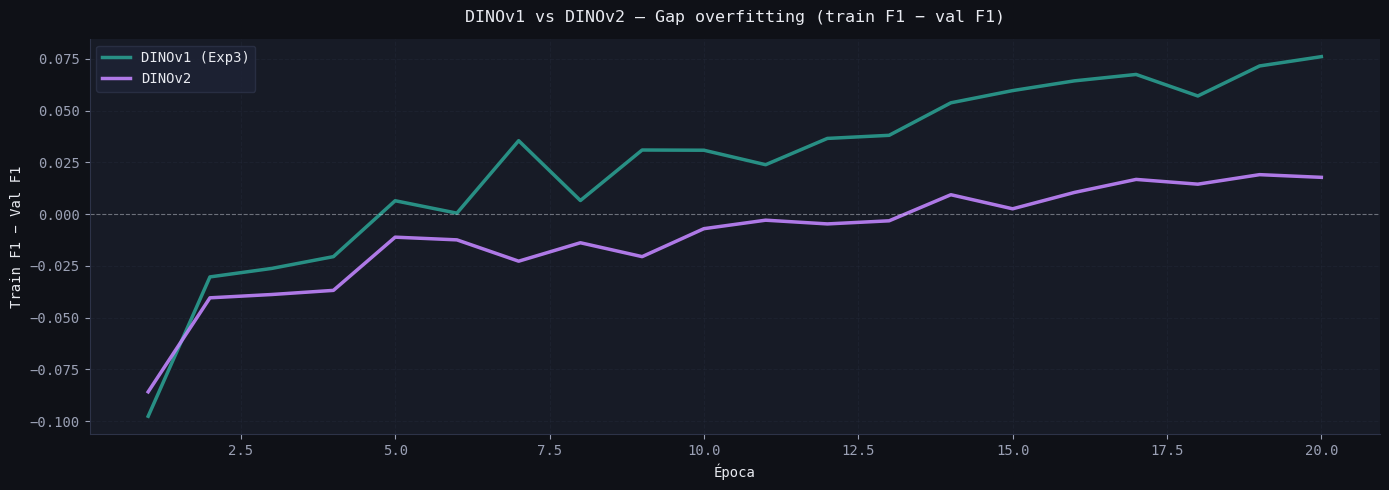

Figura guardada: dinov1_vs_v2_overfitting.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0F1117")

for label, rep, color in [
    ("DINOv1 (Exp3)", rep_v1, COLOR_V1),
    ("DINOv2",        rep_v2, COLOR_V2),
]:
    epochs = [h["epoch"]                  for h in rep["history"]]
    gap    = [h["train_f1"] - h["val_f1"] for h in rep["history"]]
    ax.plot(epochs, gap, color=color, linewidth=2.5, label=label, alpha=0.9)

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("DINOv1 vs DINOv2 — Gap overfitting (train F1 − val F1)", fontsize=12, color="#E8EAF0", pad=12)
ax.set_xlabel("Época", fontsize=10)
ax.set_ylabel("Train F1 − Val F1", fontsize=10)
ax.legend(fontsize=10, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")

plt.tight_layout()
plt.savefig("dinov1_vs_v2_overfitting.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: dinov1_vs_v2_overfitting.png")


## 9. Conclusión: DINOv1 vs DINOv2

Comparación directa con hiperparámetros idénticos (d=0.5, 20 épocas, hidden\_dim=256).

**Claves de interpretación:**
- Si DINOv2 sube **D10** notablemente → las features de mayor calidad atacan el cuello de botella.
- Si la mejora en Macro F1 viene solo de D00/D20 → el backbone más potente no resuelve la clase difícil.
- Si el gap de overfitting de DINOv2 es menor → el backbone implícitamente regulariza mejor.

---
## 10. Comparativa de 4 modelos: DINOv1, DINOv2, DINOv3-ViT, DINOv3-ConvNeXt

Todos entrenados con los mismos hiperparámetros (d=0.5, 20 épocas, hidden\_dim=256).
El único factor que varía es el **backbone de extracción de features**.

| | DINOv1 (Exp3) | DINOv2 | DINOv3-ViT | DINOv3-ConvNeXt |
|---|---|---|---|---|
| Backbone | ViT-S/16 DINOv1 | ViT-S/14 DINOv2 | ViT DINOv3 | ConvNeXt DINOv3 |
| Dropout | 0.5 | 0.5 | 0.5 | 0.5 |
| Épocas | 20 | 20 | 20 | 20 |
| Hidden dim | 256 | 256 | 256 | 256 |

In [22]:
# ── Rutas a los reports de DINOv3 ───────────────────────────────────
DINOV3_VIT_PATH  = r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2º CUATRI\PASD\BLOG\features\models\dinov3-vit\training_report.json"
DINOV3_CONV_PATH = r"C:\Users\pablo\Desktop\Uni 23 24\Curso 3\2º CUATRI\PASD\BLOG\features\models\dinov3-convnext\training_report.json"

# En Colab con Google Drive:
# DINOV3_VIT_PATH  = "/content/drive/MyDrive/PASD BLOG/models/dinov3_vit/training_report_20_epochs_256_hidden.json"
# DINOV3_CONV_PATH = "/content/drive/MyDrive/PASD BLOG/models/dinov3_convnext/training_report_20_epochs_256_hidden.json"

with open(DINOV3_VIT_PATH, encoding="utf-8") as f:
    rep_v3_vit = json.load(f)
with open(DINOV3_CONV_PATH, encoding="utf-8") as f:
    rep_v3_conv = json.load(f)

COLOR_V3_VIT  = "#FB8500"   # naranja  — DINOv3-ViT
COLOR_V3_CONV = "#E63946"   # rojo     — DINOv3-ConvNeXt

models_4 = [
    ("DINOv1 (Exp3)",   rep_v1,      COLOR_V1),
    ("DINOv2",          rep_v2,      COLOR_V2),
    ("DINOv3-ViT",      rep_v3_vit,  COLOR_V3_VIT),
    ("DINOv3-ConvNeXt", rep_v3_conv, COLOR_V3_CONV),
]

for label, rep, _ in models_4:
    n_ep = len(rep["history"])
    mf1  = rep["test_metrics"]["macro_f1"]
    print(f"  {label:<20}: {n_ep} épocas | Macro F1 test = {mf1:.4f} ✅")


  DINOv1 (Exp3)       : 20 épocas | Macro F1 test = 0.7298 ✅
  DINOv2              : 20 épocas | Macro F1 test = 0.7523 ✅
  DINOv3-ViT          : 20 épocas | Macro F1 test = 0.7335 ✅
  DINOv3-ConvNeXt     : 20 épocas | Macro F1 test = 0.7250 ✅


In [23]:
print(f"{'Modelo':<24} {'Macro F1':>9} {'D00 F1':>8} {'D10 F1':>8} {'D20 F1':>8} {'Exact Acc':>10} {'Train F1':>10} {'Val loss':>10} {'Mejor ep':>9}")
print("─" * 110)

for label, rep, _ in models_4:
    tm       = rep["test_metrics"]
    hist     = rep["history"]
    best_ep  = max(hist, key=lambda h: h["val_f1"])["epoch"]
    print(
        f"  {label:<22} "
        f"{tm['macro_f1']:>9.4f} "
        f"{tm['D00']['f1']:>8.4f} "
        f"{tm['D10']['f1']:>8.4f} "
        f"{tm['D20']['f1']:>8.4f} "
        f"{tm['exact_accuracy']:>10.4f} "
        f"{hist[-1]['train_f1']:>10.4f} "
        f"{hist[-1]['val_loss']:>10.4f} "
        f"{best_ep:>9} "
    )

Modelo                    Macro F1   D00 F1   D10 F1   D20 F1  Exact Acc   Train F1   Val loss  Mejor ep
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  DINOv1 (Exp3)             0.7298   0.8053   0.6157   0.7684     0.5004     0.8216     0.5401        11 
  DINOv2                    0.7523   0.8119   0.6562   0.7890     0.5208     0.7756     0.4940        13 
  DINOv3-ViT                0.7335   0.7939   0.6345   0.7723     0.5027     0.7921     0.5156         9 
  DINOv3-ConvNeXt           0.7250   0.7931   0.6192   0.7628     0.4867     0.7609     0.5293        20 


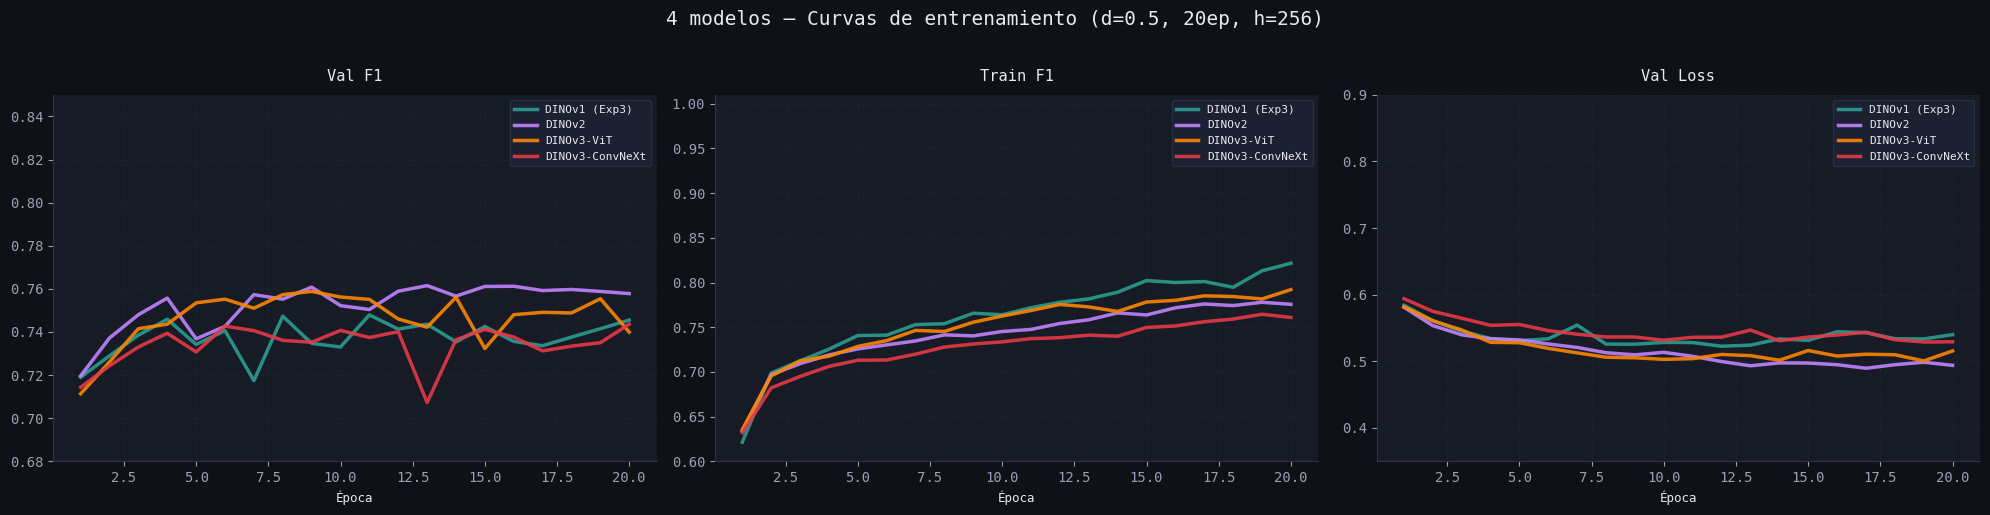

Figura guardada: 4modelos_curvas.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor="#0F1117")
fig.suptitle("4 modelos — Curvas de entrenamiento (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

titles   = ["Val F1", "Train F1", "Val Loss"]
keys_y   = ["val_f1", "train_f1", "val_loss"]
y_limits = [(0.68, 0.85), (0.60, 1.01), (0.35, 0.90)]

for ax, title, key, ylim in zip(axes, titles, keys_y, y_limits):
    for label, rep, color in models_4:
        epochs = [h["epoch"] for h in rep["history"]]
        values = [h[key]     for h in rep["history"]]
        ax.plot(epochs, values, color=color, linewidth=2.5, label=label, alpha=0.9)

    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_xlabel("Época", fontsize=9)
    ax.set_ylim(ylim)
    ax.legend(fontsize=8, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="best")

plt.tight_layout()
plt.savefig("4modelos_curvas.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: 4modelos_curvas.png")


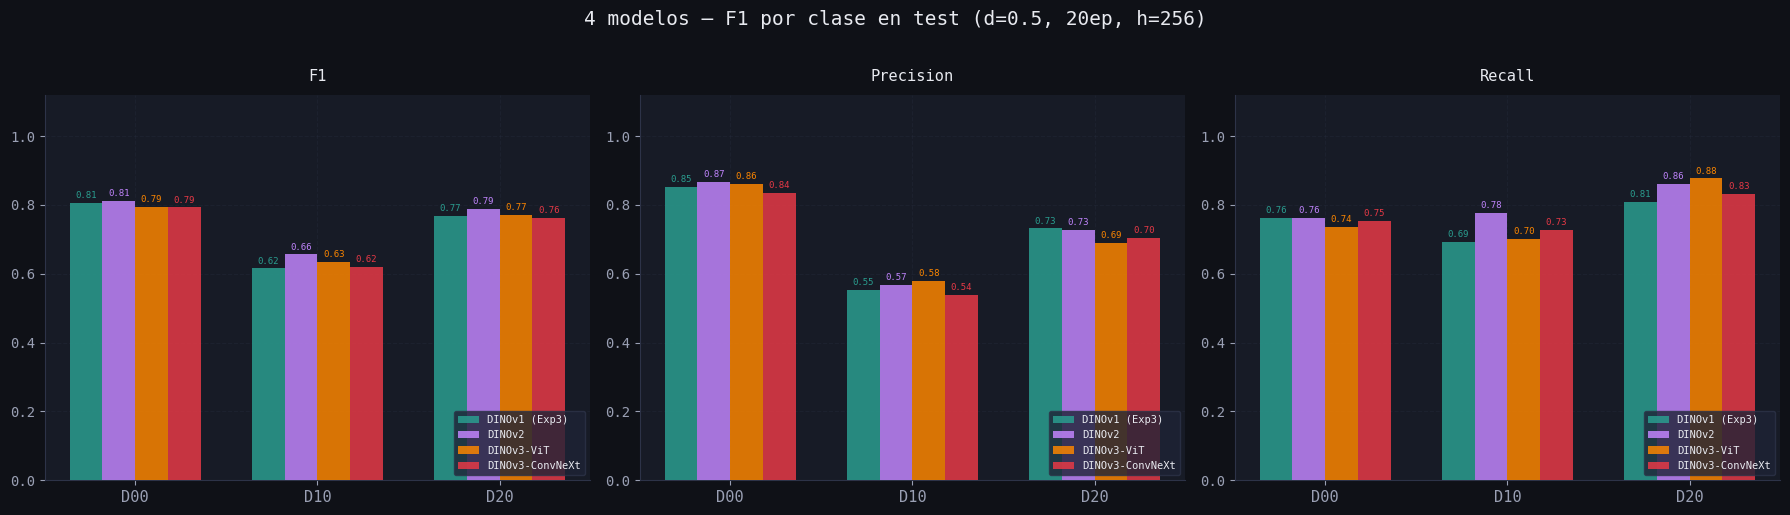

Figura guardada: 4modelos_f1_clase.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0F1117")
fig.suptitle("4 modelos — F1 por clase en test (d=0.5, 20ep, h=256)",
             fontsize=14, color="#E8EAF0", y=1.02)

metrics_to_plot = ["f1", "precision", "recall"]
metric_titles   = ["F1", "Precision", "Recall"]

n_models = len(models_4)
width    = 0.18
offsets  = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for ax, metric, title in zip(axes, metrics_to_plot, metric_titles):
    x = np.arange(len(CLASSES))
    for (label, rep, color), off in zip(models_4, offsets):
        vals = [rep["test_metrics"][cls][metric] for cls in CLASSES]
        bars = ax.bar(x + off, vals, width, color=color, alpha=0.85,
                      label=label, zorder=3, linewidth=0)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=6.5, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, fontsize=11)
    ax.set_title(title, fontsize=11, color="#E8EAF0", pad=10)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=7.5, facecolor="#1E2336", edgecolor="#2D3348",
              labelcolor="#E8EAF0", loc="lower right")

plt.tight_layout()
plt.savefig("4modelos_f1_clase.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: 4modelos_f1_clase.png")


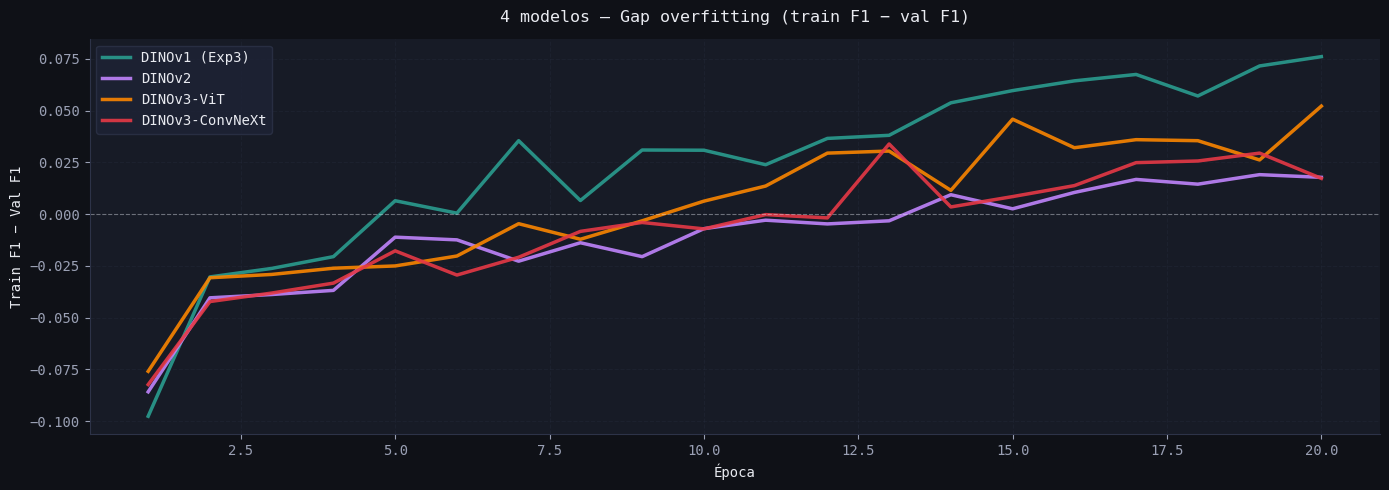

Figura guardada: 4modelos_overfitting.png


In [26]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor="#0F1117")

for label, rep, color in models_4:
    epochs = [h["epoch"]                  for h in rep["history"]]
    gap    = [h["train_f1"] - h["val_f1"] for h in rep["history"]]
    ax.plot(epochs, gap, color=color, linewidth=2.5, label=label, alpha=0.9)

ax.axhline(0, color="#E8EAF0", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("4 modelos — Gap overfitting (train F1 − val F1)", fontsize=12, color="#E8EAF0", pad=12)
ax.set_xlabel("Época", fontsize=10)
ax.set_ylabel("Train F1 − Val F1", fontsize=10)
ax.legend(fontsize=10, facecolor="#1E2336", edgecolor="#2D3348", labelcolor="#E8EAF0")

plt.tight_layout()
plt.savefig("4modelos_overfitting.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Figura guardada: 4modelos_overfitting.png")


## 11. Conclusión: los cuatro modelos

Comparativa controlada con hiperparámetros idénticos (d=0.5, 20 épocas, hidden\_dim=256); el único factor que varía es el backbone de extracción de features.

**Ejes de análisis:**
- **Macro F1**: ¿mejora global al escalar el backbone?
- **D10 F1**: cuello de botella persistente — ¿algún backbone lo rompe?
- **Gap overfitting**: un backbone más potente puede regularizar implícitamente.
- **DINOv3-ViT vs DINOv3-ConvNeXt**: dentro de la misma versión, ¿Transformer o convolucional?